# K-NN

## Librerías y datos

In [14]:
# --- Librerías estándar ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modelos de machine learning ---
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

# --- Validación y optimización ---
from sklearn.model_selection import StratifiedKFold
from skopt import BayesSearchCV

# --- Métricas de evaluación ---
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# --- Manejo de desbalance de clases ---
from imblearn.over_sampling import SMOTE



In [15]:
import joblib

ruta_base = r'C:\Users\PC\Desktop\ML_trabajo\jbook_parcial\docs\\'

X_train = joblib.load(ruta_base + 'X_train.pkl')
X_test = joblib.load(ruta_base + 'X_test.pkl')
y_train = joblib.load(ruta_base + 'y_train.pkl')
y_test = joblib.load(ruta_base + 'y_test.pkl')



In [9]:
# Ver distribución de clases
print("\nDistribución en y_train:")
print(pd.Series(y_train).value_counts())
print(pd.Series(y_train).value_counts(normalize=True) * 100)

print("\nDistribución en y_test:")
print(pd.Series(y_test).value_counts())
print(pd.Series(y_test).value_counts(normalize=True) * 100)


Distribución en y_train:
EsFraude
0.0    45590
1.0    16530
Name: count, dtype: int64
EsFraude
0.0    73.390212
1.0    26.609788
Name: proportion, dtype: float64

Distribución en y_test:
EsFraude
0.0    11398
1.0     4133
Name: count, dtype: int64
EsFraude
0.0    73.388706
1.0    26.611294
Name: proportion, dtype: float64


# K-NN

c:\Users\PC\miniconda3\envs\ml_venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

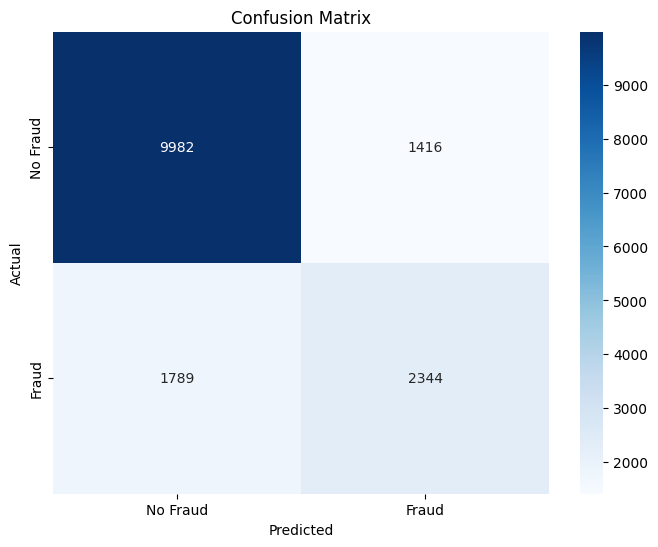

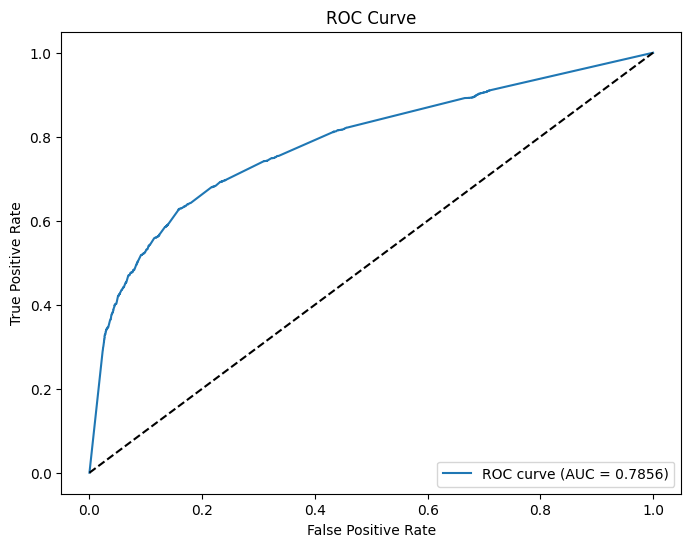

  Model  Precision    Recall  F1 Score       AUC
0   KNN   0.623404  0.567143  0.593944  0.785581


In [ ]:


# Paso 1: Aplicar SMOTE a las variables X_train e y_train para balancear las clases
smote = SMOTE(random_state=42)  # Crear el objeto SMOTE
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)  # Balancear clases

# Paso 2: Modelo KNN en CPU
knn = KNeighborsClassifier()

# Paso 3: Configurar la búsqueda de hiperparámetros usando BayesSearchCV
param_space = {
    'n_neighbors': (1, 50),  # Número de vecinos, rango de 1 a 50
    'metric': ['euclidean', 'manhattan', 'minkowski'],  # Métricas para el cálculo de distancias
    'weights': ['uniform', 'distance']  # Pesos de los vecinos
}

# Paso 4: Validación cruzada
cv = StratifiedKFold(n_splits=5)

# Paso 5: Configurar BayesSearchCV
bayes_search = BayesSearchCV(
    knn,
    param_space,
    n_iter=30,  # Número de iteraciones de optimización
    cv=cv,
    scoring='roc_auc',  # AUC es la métrica que se quiere maximizar
    verbose=3,  # Para ver el progreso de la optimización
    n_jobs=-1  # Usa todos los núcleos de CPU disponibles
)

# Paso 6: Entrenar el modelo con los datos balanceados
bayes_search.fit(X_train_res, y_train_res)

# Mejor modelo encontrado
best_model = bayes_search.best_estimator_

# Paso 7: Evaluar el rendimiento del modelo sobre el conjunto de prueba
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]  # Probabilidades de la clase positiva

# Calcular métricas de rendimiento
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Mostrar métricas
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")

# Paso 8: Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Paso 9: Generar la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Paso 10: Guardar los resultados en una tabla
results = pd.DataFrame({
    'Model': ['KNN'],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1],
    'AUC': [roc_auc]
})

# Mostrar la tabla de resultados
print(results)




se ha empleado la validación cruzada mediante la técnica de StratifiedKFold con 5 particiones, la cual resulta especialmente adecuada para problemas de clasificación con clases desbalanceadas, como es el caso del fraude financiero. Esta técnica asegura que cada subconjunto generado durante el proceso de validación preserve la proporción original de clases entre fraude y no fraude, lo que permite una evaluación más representativa y confiable del rendimiento del modelo. A diferencia de la validación cruzada estándar, que podría generar divisiones desproporcionadas y conducir a estimaciones sesgadas, StratifiedKFold garantiza que el aprendizaje del modelo se realice sobre muestras equilibradas, mejorando así la estabilidad y generalización de los resultados.

# Logistic Regression

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

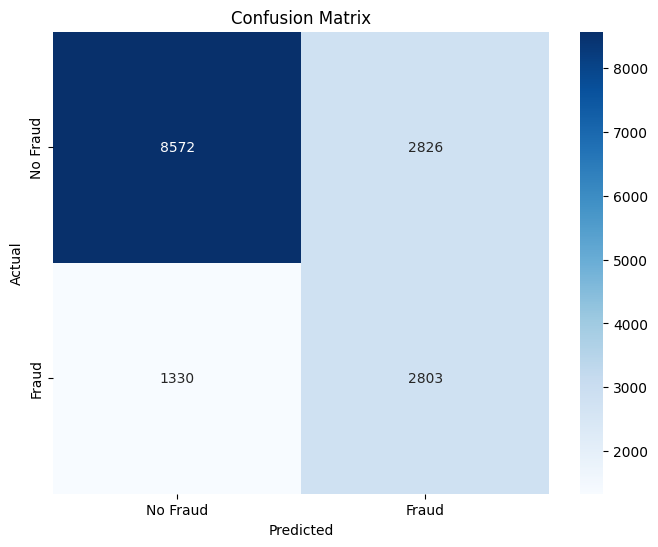

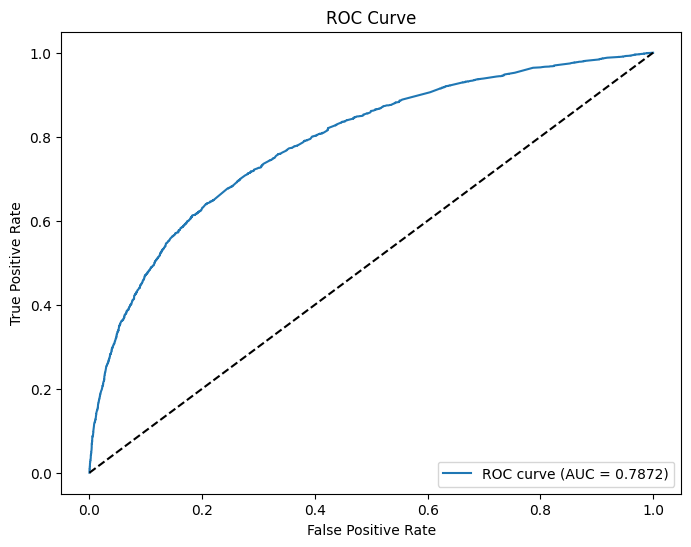

                 Model  Precision  Recall  F1 Score       AUC
0  Logistic Regression   0.497957  0.6782  0.574268  0.787182


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from skopt import BayesSearchCV

# Paso 1: Definir el modelo base
logreg = LogisticRegression(solver='saga', max_iter=10000, class_weight='balanced')

# Paso 2: Espacio de búsqueda para hiperparámetros
param_space = {
    'C': (1e-3, 100.0, 'log-uniform'),  # Regularización
    'penalty': ['l1', 'l2']  # Tipos de penalización
}

# Paso 3: Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5)

# Paso 4: Configurar la búsqueda bayesiana
bayes_search = BayesSearchCV(
    estimator=logreg,
    search_spaces=param_space,
    scoring='roc_auc',
    n_iter=30,
    cv=cv,
    n_jobs=-1,
    verbose=3,
    random_state=42
)

# Paso 5: Entrenamiento
bayes_search.fit(X_train, y_train)

# Paso 6: Evaluación
best_model = bayes_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Tabla de resultados
results = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1],
    'AUC': [roc_auc]
})

print(results)


# Bayesian Classification

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

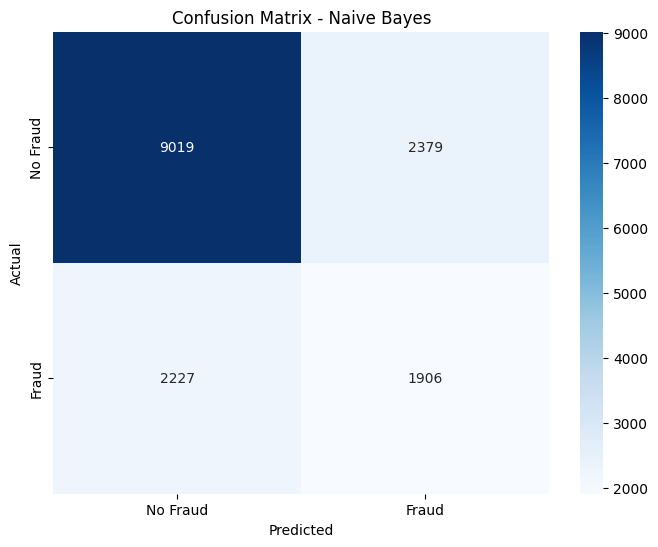

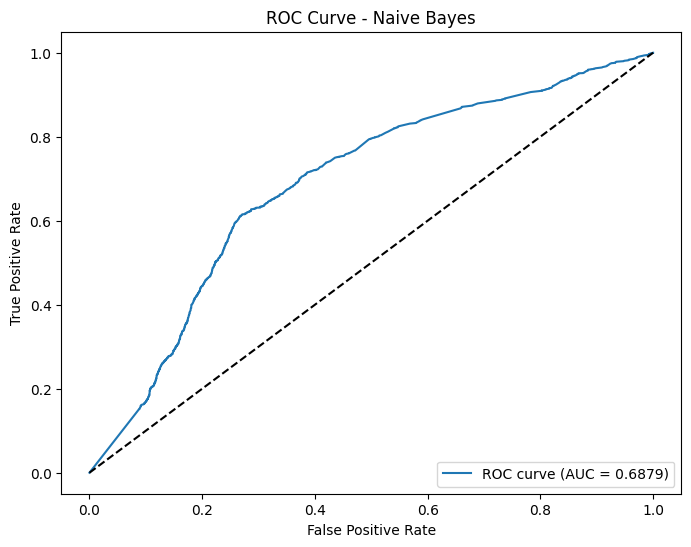

         Model  Precision    Recall  F1 Score       AUC
0  Naive Bayes   0.444807  0.461166  0.452839  0.687919


In [16]:
from sklearn.naive_bayes import GaussianNB
from skopt import BayesSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Paso 1: Modelo base
nb_model = GaussianNB()

# Paso 2: (opcional) Espacio de búsqueda para el parámetro var_smoothing
param_space_nb = {
    'var_smoothing': (1e-11, 1e-7, 'log-uniform')  # Pequeña cantidad agregada a la varianza
}

# Paso 3: Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5)

# Paso 4: Búsqueda bayesiana
bayes_search_nb = BayesSearchCV(
    estimator=nb_model,
    search_spaces=param_space_nb,
    scoring='roc_auc',
    n_iter=20,
    cv=cv,
    n_jobs=-1,
    verbose=3,
    random_state=42
)

# Paso 5: Entrenamiento
bayes_search_nb.fit(X_train, y_train)

# Paso 6: Evaluación
best_nb_model = bayes_search_nb.best_estimator_
y_pred_nb = best_nb_model.predict(X_test)
y_prob_nb = best_nb_model.predict_proba(X_test)[:, 1]

# Métricas
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
roc_auc_nb = roc_auc_score(y_test, y_prob_nb)

print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"F1 Score: {f1_nb:.4f}")
print(f"AUC: {roc_auc_nb:.4f}")

# Matriz de confusión
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Curva ROC
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, label=f'ROC curve (AUC = {roc_auc_nb:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc='lower right')
plt.show()

# Tabla de resultados
results_nb = pd.DataFrame({
    'Model': ['Naive Bayes'],
    'Precision': [precision_nb],
    'Recall': [recall_nb],
    'F1 Score': [f1_nb],
    'AUC': [roc_auc_nb]
})

print(results_nb)


# Decision Tree

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

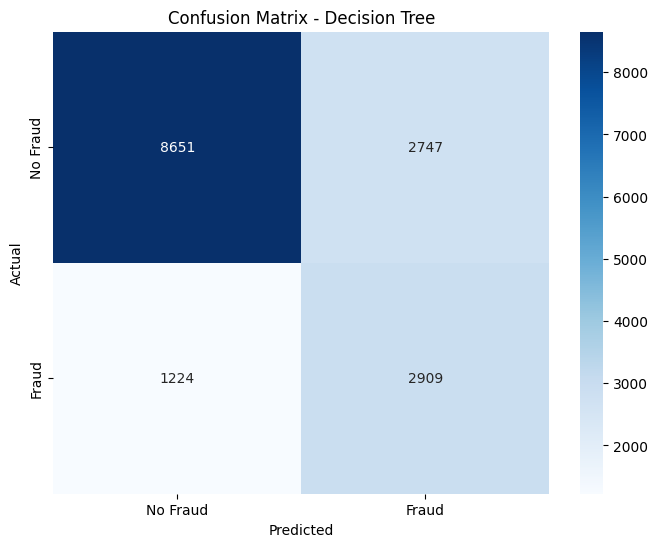

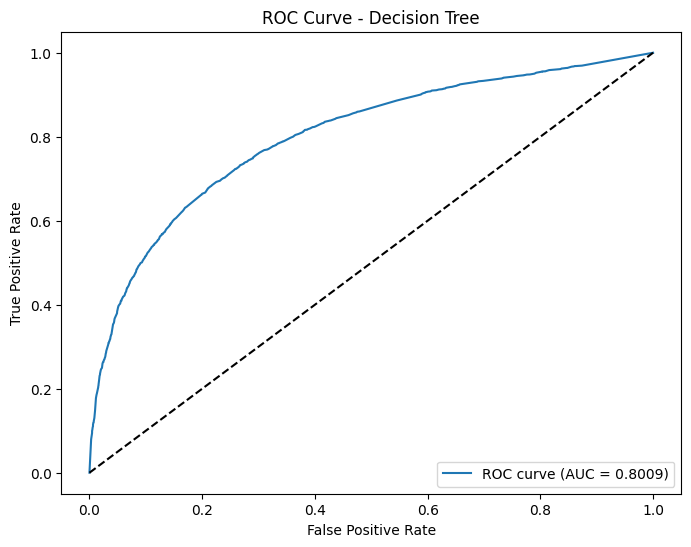

           Model  Precision    Recall  F1 Score       AUC
0  Decision Tree   0.514321  0.703847  0.594341  0.800893


In [17]:
from sklearn.tree import DecisionTreeClassifier
from skopt import BayesSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Paso 1: Modelo base
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Paso 2: Espacio de búsqueda para hiperparámetros
param_space_dt = {
    'max_depth': (3, 30),                      # Profundidad del árbol
    'min_samples_split': (2, 20),              # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': (1, 20),               # Mínimo de muestras en una hoja
    'max_features': ['sqrt', 'log2', None]     # Número de características a considerar al dividir
}

# Paso 3: Validación cruzada
cv = StratifiedKFold(n_splits=5)

# Paso 4: Búsqueda bayesiana
bayes_search_dt = BayesSearchCV(
    estimator=dt_model,
    search_spaces=param_space_dt,
    scoring='roc_auc',
    n_iter=30,
    cv=cv,
    n_jobs=-1,
    verbose=3,
    random_state=42
)

# Paso 5: Entrenamiento
bayes_search_dt.fit(X_train, y_train)

# Paso 6: Evaluación
best_dt_model = bayes_search_dt.best_estimator_
y_pred_dt = best_dt_model.predict(X_test)
y_prob_dt = best_dt_model.predict_proba(X_test)[:, 1]

# Métricas
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1 Score: {f1_dt:.4f}")
print(f"AUC: {roc_auc_dt:.4f}")

# Matriz de confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Curva ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'ROC curve (AUC = {roc_auc_dt:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc='lower right')
plt.show()

# Tabla de resultados
results_dt = pd.DataFrame({
    'Model': ['Decision Tree'],
    'Precision': [precision_dt],
    'Recall': [recall_dt],
    'F1 Score': [f1_dt],
    'AUC': [roc_auc_dt]
})

print(results_dt)


# Random Forest

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

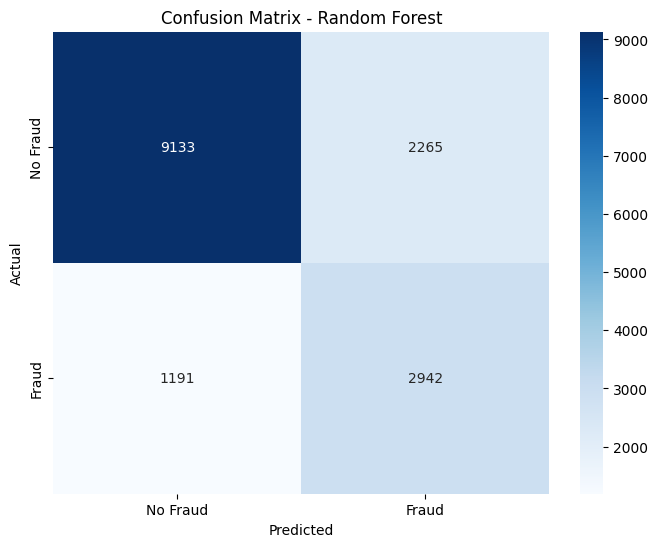

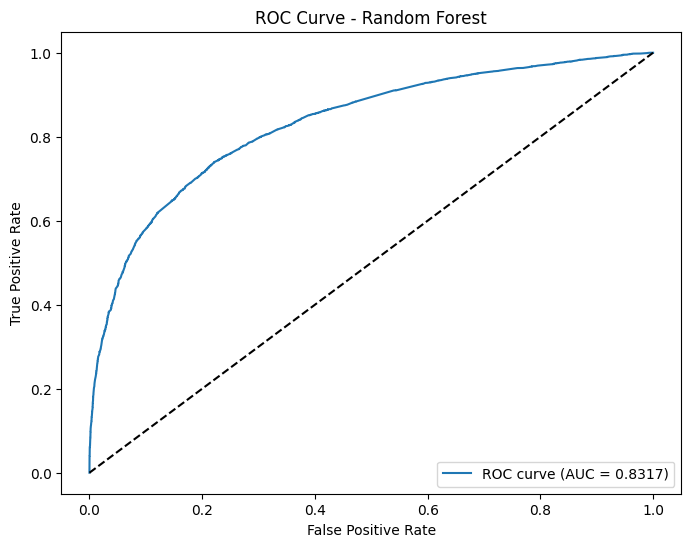

           Model  Precision    Recall  F1 Score       AUC
0  Random Forest   0.565009  0.711832  0.629979  0.831674


In [18]:
from sklearn.ensemble import RandomForestClassifier
from skopt import BayesSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Paso 1: Modelo base
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Paso 2: Espacio de búsqueda para hiperparámetros
param_space_rf = {
    'n_estimators': (50, 300),               # Número de árboles
    'max_depth': (5, 30),                    # Profundidad máxima de los árboles
    'min_samples_split': (2, 20),            # Mínimo de muestras para dividir
    'min_samples_leaf': (1, 20),             # Mínimo de muestras por hoja
    'max_features': ['sqrt', 'log2', None]   # Número de características consideradas en cada split
}

# Paso 3: Validación cruzada
cv = StratifiedKFold(n_splits=5)

# Paso 4: Búsqueda bayesiana
bayes_search_rf = BayesSearchCV(
    estimator=rf_model,
    search_spaces=param_space_rf,
    scoring='roc_auc',
    n_iter=30,
    cv=cv,
    n_jobs=-1,
    verbose=3,
    random_state=42
)

# Paso 5: Entrenamiento
bayes_search_rf.fit(X_train, y_train)

# Paso 6: Evaluación
best_rf_model = bayes_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

# Métricas
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"AUC: {roc_auc_rf:.4f}")

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Curva ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'ROC curve (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()

# Tabla de resultados
results_rf = pd.DataFrame({
    'Model': ['Random Forest'],
    'Precision': [precision_rf],
    'Recall': [recall_rf],
    'F1 Score': [f1_rf],
    'AUC': [roc_auc_rf]
})

print(results_rf)


# XGBoost

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

c:\Users\PC\miniconda3\envs\ml_venv\lib\site-packages\xgboost\core.py:158: UserWarning: [13:55:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Precision: 0.7474
Recall: 0.5212
F1 Score: 0.6141
AUC: 0.8365


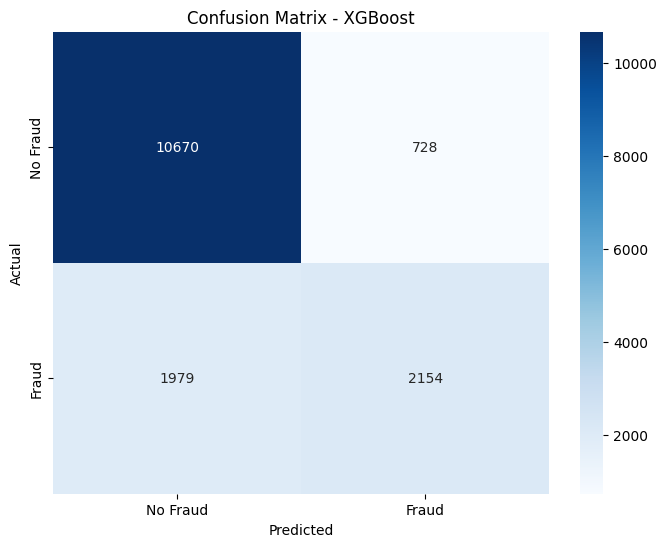

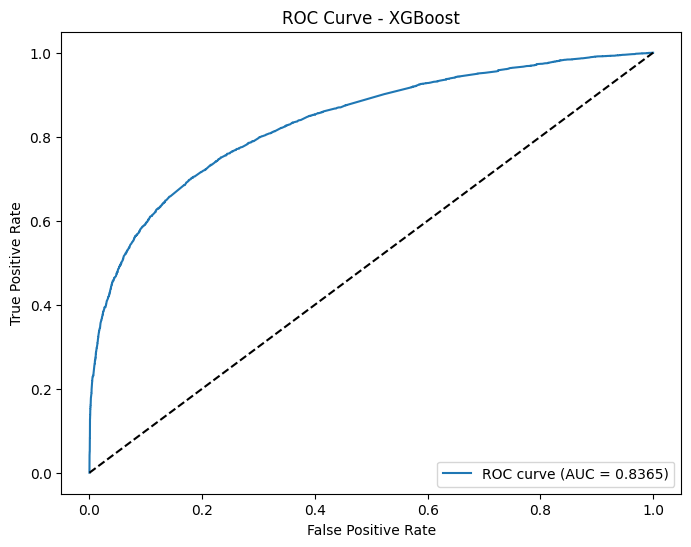

     Model  Precision    Recall  F1 Score       AUC
0  XGBoost   0.747398  0.521171  0.614113  0.836542


In [19]:
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Paso 1: Modelo base
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    scale_pos_weight=1,  # Puedes ajustar esto si hay desbalance
    random_state=42,
    n_jobs=-1
)

# Paso 2: Espacio de búsqueda
param_space_xgb = {
    'n_estimators': (50, 300),
    'max_depth': (3, 15),
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'gamma': (0, 5.0),
    'reg_lambda': (1e-3, 10.0, 'log-uniform'),
    'reg_alpha': (1e-3, 10.0, 'log-uniform')
}

# Paso 3: Validación cruzada
cv = StratifiedKFold(n_splits=5)

# Paso 4: Búsqueda bayesiana
bayes_search_xgb = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_space_xgb,
    scoring='roc_auc',
    n_iter=30,
    cv=cv,
    n_jobs=-1,
    verbose=3,
    random_state=42
)

# Paso 5: Entrenamiento
bayes_search_xgb.fit(X_train, y_train)

# Paso 6: Evaluación
best_xgb_model = bayes_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)
y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Métricas
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"AUC: {roc_auc_xgb:.4f}")

# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Curva ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'ROC curve (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.show()

# Tabla de resultados
results_xgb = pd.DataFrame({
    'Model': ['XGBoost'],
    'Precision': [precision_xgb],
    'Recall': [recall_xgb],
    'F1 Score': [f1_xgb],
    'AUC': [roc_auc_xgb]
})

print(results_xgb)


# SVM

In [20]:
from sklearn.svm import SVC
from skopt import BayesSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Paso 1: Modelo base
svm_model = SVC(probability=True, class_weight='balanced', random_state=42)

# Paso 2: Espacio de búsqueda
param_space_svm = {
    'C': (1e-3, 100.0, 'log-uniform'),
    'gamma': (1e-4, 1.0, 'log-uniform'),
    'kernel': ['rbf']  # Puedes agregar 'linear' o 'poly' si lo deseas
}

# Paso 3: Validación cruzada
cv = StratifiedKFold(n_splits=5)

# Paso 4: Búsqueda bayesiana
bayes_search_svm = BayesSearchCV(
    estimator=svm_model,
    search_spaces=param_space_svm,
    scoring='roc_auc',
    n_iter=30,
    cv=cv,
    n_jobs=-1,
    verbose=3,
    random_state=42
)

# Paso 5: Entrenamiento
bayes_search_svm.fit(X_train, y_train)

# Paso 6: Evaluación
best_svm_model = bayes_search_svm.best_estimator_
y_pred_svm = best_svm_model.predict(X_test)
y_prob_svm = best_svm_model.predict_proba(X_test)[:, 1]

# Métricas
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1 Score: {f1_svm:.4f}")
print(f"AUC: {roc_auc_svm:.4f}")

# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Curva ROC
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'ROC curve (AUC = {roc_auc_svm:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.show()

# Tabla de resultados
results_svm = pd.DataFrame({
    'Model': ['SVM'],
    'Precision': [precision_svm],
    'Recall': [recall_svm],
    'F1 Score': [f1_svm],
    'AUC': [roc_auc_svm]
})

print(results_svm)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


KeyboardInterrupt: 

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

c:\Users\PC\miniconda3\envs\ml_venv\lib\site-packages\xgboost\core.py:158: UserWarning: [17:43:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\PC\miniconda3\envs\ml_venv\lib\site-packages\xgboost\core.py:158: UserWarning: [17:43:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Precision: 0.7581
Recall: 0.5110
F1 Score: 0.6105
AUC: 0.8391


c:\Users\PC\miniconda3\envs\ml_venv\lib\site-packages\xgboost\core.py:158: UserWarning: [17:43:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\PC\miniconda3\envs\ml_venv\lib\site-packages\xgboost\core.py:158: UserWarning: [17:43:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set th

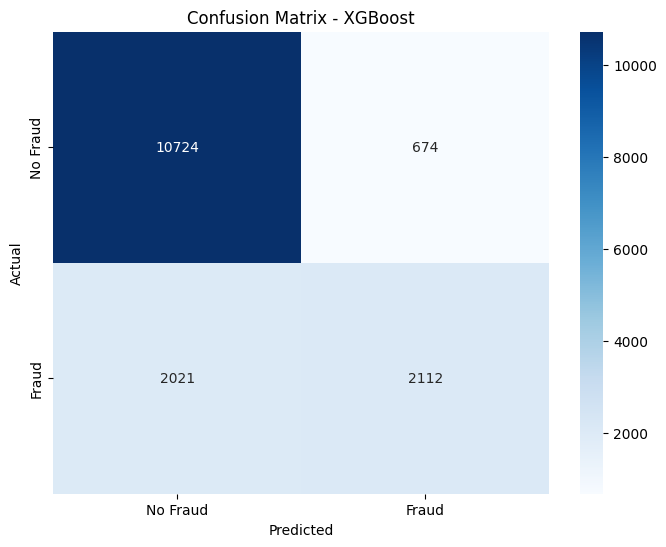

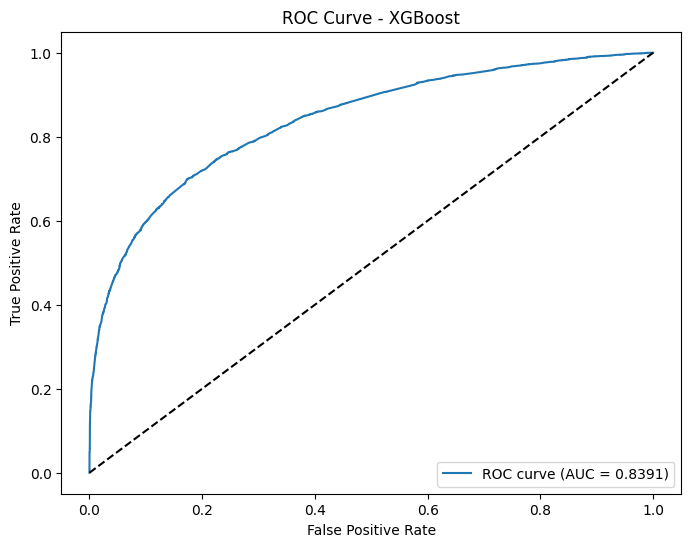

     Model  Precision    Recall  F1 Score      AUC
0  XGBoost   0.758076  0.511009  0.610493  0.83912


In [13]:

# Paso 1: Modelo base (con GPU habilitada)
xgb_model = XGBClassifier(
    tree_method='gpu_hist',  # Usa GPU
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Paso 2: Espacio de búsqueda
param_space_xgb = {
    'n_estimators': (50, 300),
    'max_depth': (3, 10),
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'subsample': (0.5, 1.0, 'uniform'),
    'colsample_bytree': (0.5, 1.0, 'uniform'),
    'gamma': (0, 5.0),
    'reg_alpha': (0.0, 5.0),
    'reg_lambda': (0.0, 5.0)
}

# Paso 3: Validación cruzada
cv = StratifiedKFold(n_splits=5)

# Paso 4: Búsqueda bayesiana
bayes_search_xgb = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_space_xgb,
    scoring='roc_auc',
    n_iter=30,
    cv=cv,
    n_jobs=-1,
    verbose=3,
    random_state=42
)

# Paso 5: Entrenamiento
bayes_search_xgb.fit(X_train, y_train)

# Paso 6: Evaluación
best_xgb_model = bayes_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)
y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Métricas
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"AUC: {roc_auc_xgb:.4f}")

# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Curva ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'ROC curve (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.show()

# Tabla de resultados
results_xgb = pd.DataFrame({
    'Model': ['XGBoost'],
    'Precision': [precision_xgb],
    'Recall': [recall_xgb],
    'F1 Score': [f1_xgb],
    'AUC': [roc_auc_xgb]
})

print(results_xgb)


# MLP

In [18]:
# --- Librerías necesarias ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from skopt import BayesSearchCV
from skopt.space import Real, Categorical

# --- Paso 1: Definir el modelo base ---
mlp_model = MLPClassifier(max_iter=300, random_state=42)

# --- Paso 2: Espacio de búsqueda para hiperparámetros ---
param_space_mlp = {
    'hidden_layer_sizes': Categorical([(50,), (100,), (50, 50), (100, 50), (100, 100)]),
    'activation': Categorical(['relu', 'tanh']),
    'alpha': Real(1e-5, 1e-2, prior='log-uniform'),
    'learning_rate_init': Real(1e-4, 1e-1, prior='log-uniform')
}

# --- Paso 3: Validación cruzada estratificada ---
cv = StratifiedKFold(n_splits=5)

# --- Paso 4: Configurar búsqueda bayesiana ---
bayes_search_mlp = BayesSearchCV(
    estimator=mlp_model,
    search_spaces=param_space_mlp,
    scoring='roc_auc',
    n_iter=30,
    cv=cv,
    n_jobs=-1,
    verbose=3,
    random_state=42
)

# --- Paso 5: Entrenamiento ---
try:
    bayes_search_mlp.fit(X_train, y_train)

    # --- Paso 6: Evaluación ---
    best_mlp_model = bayes_search_mlp.best_estimator_
    y_pred = best_mlp_model.predict(X_test)
    y_prob = best_mlp_model.predict_proba(X_test)[:, 1]

    # Métricas
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Fraud', 'Fraud'],
                yticklabels=['No Fraud', 'Fraud'])
    plt.title('Matriz de Confusión - MLP')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

    # Curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC - MLP')
    plt.legend(loc='lower right')
    plt.show()

    # Tabla de resultados
    results = pd.DataFrame({
        'Model': ['MLP'],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1],
        'AUC': [roc_auc]
    })

    print(results)

    # Guardar los mejores hiperparámetros (opcional)
    best_params = bayes_search_mlp.best_params_
    print("Mejores hiperparámetros encontrados:")
    print(best_params)

except ValueError as e:
    print(f"Ocurrió un ValueError durante el entrenamiento: {e}")


Ocurrió un ValueError durante el entrenamiento: can only convert an array of size 1 to a Python scalar


# Velocidad del viento

In [20]:
# Modificar la ruta del archivo CSV
file_path = r'C:\Users\PC\Desktop\ML_trabajo\jbook_parcial\docs\data_treino_dv_df_2000_2010.csv'
df = pd.read_csv(file_path)


In [21]:
df.columns

Index(['HORA (UTC)', 'VENTO, DIREï¿½ï¿½O HORARIA (gr) (ï¿½ (gr))',
       'VENTO, VELOCIDADE HORARIA (m/s)',
       'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
       'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
       'TEMPERATURA Mï¿½XIMA NA HORA ANT. (AUT) (ï¿½C)',
       'TEMPERATURA Mï¿½NIMA NA HORA ANT. (AUT) (ï¿½C)',
       'UMIDADE RELATIVA DO AR, HORARIA (%)',
       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
       'PRECIPITAï¿½ï¿½O TOTAL, HORï¿½RIO (mm)', 'VENTO, RAJADA MAXIMA (m/s)',
       'PRESSï¿½O ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
       'PRESSï¿½O ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)'],
      dtype='object')

In [26]:
# Limpiar los nombres de las columnas para reemplazar caracteres especiales
df.columns = df.columns.str.replace('ï¿½','', regex=True)  # Limpiar caracteres extraños

# Renombrar las columnas con nombres más fáciles de manejar
df.rename(columns={
    'HORA (UTC)': 'hora_utc',
    'VENTO, DIREï¿½ï¿½O HORARIA (gr) (ï¿½ (gr))': 'direccion_viento',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'velocidad_viento',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'humedad_max_hora_ant',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'humedad_min_hora_ant',
    'TEMPERATURA Mï¿½XIMA NA HORA ANT. (AUT) (ï¿½C)': 'temp_max_hora_ant',
    'TEMPERATURA Mï¿½NIMA NA HORA ANT. (AUT) (ï¿½C)': 'temp_min_hora_ant',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'humedad_relativa_ar',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'presion_atmosferica',
    'PRECIPITAï¿½ï¿½O TOTAL, HORï¿½RIO (mm)': 'precipitacion_total',
    'VENTO, RAJADA MAXIMA (m/s)': 'rajada_max_viento',
    'PRESSï¿½O ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'presion_max_hora_ant',
    'PRESSï¿½O ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'presion_min_hora_ant'
}, inplace=True)

# Ver las columnas renombradas para confirmar
print(df.columns)


Index(['hora_utc', 'VENTO, DIREO HORARIA (gr) ( (gr))', 'velocidad_viento',
       'humedad_max_hora_ant', 'humedad_min_hora_ant',
       'TEMPERATURA MXIMA NA HORA ANT. (AUT) (C)',
       'TEMPERATURA MNIMA NA HORA ANT. (AUT) (C)', 'humedad_relativa_ar',
       'presion_atmosferica', 'PRECIPITAO TOTAL, HORRIO (mm)',
       'rajada_max_viento', 'PRESSO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
       'PRESSO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)'],
      dtype='object')


In [29]:
# Seleccionar las variables explicativas y la variable objetivo
features = [col for col in df.columns if col != 'velocidad_viento' and col != 'hora_utc']
target = 'velocidad_viento'

X = df[features]
y = df[target]

# Verificar las variables seleccionadas
print(f"Variables explicativas: {features}")
print(f"Variable objetivo: {target}")
print(f"Dimensiones del dataset: {df.shape}")


Variables explicativas: ['VENTO, DIREO HORARIA (gr) ( (gr))', 'humedad_max_hora_ant', 'humedad_min_hora_ant', 'TEMPERATURA MXIMA NA HORA ANT. (AUT) (C)', 'TEMPERATURA MNIMA NA HORA ANT. (AUT) (C)', 'humedad_relativa_ar', 'presion_atmosferica', 'PRECIPITAO TOTAL, HORRIO (mm)', 'rajada_max_viento', 'PRESSO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)', 'PRESSO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)']
Variable objetivo: velocidad_viento
Dimensiones del dataset: (87693, 13)


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np
import pandas as pd

# Paso 2: Dividir los datos en conjunto de entrenamiento y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar las dimensiones de las particiones
print(f"Tamaño conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño conjunto de prueba: {X_test.shape}")

# Paso 3: Entrenar los modelos y evaluar
# Definir los modelos a evaluar
modelos = {
    'Regresión Lineal': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Árbol de Decisión': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# Inicializar un diccionario para guardar los resultados
resultados = {}

# Entrenar y evaluar cada modelo
for nombre_modelo, modelo in modelos.items():
    print(f"\nEntrenando el modelo: {nombre_modelo}")
    # Entrenar el modelo
    modelo.fit(X_train, y_train)
    
    # Realizar predicciones
    y_pred = modelo.predict(X_test)
    
    # Calcular las métricas de rendimiento
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Guardar los resultados
    resultados[nombre_modelo] = {
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

# Mostrar los resultados
resultados_df = pd.DataFrame(resultados).T
print("\nResultados de evaluación de modelos:")
print(resultados_df)

# Paso 4: Identificar el mejor modelo basado en el RMSE (el más bajo es el mejor)
mejor_modelo = resultados_df['RMSE'].idxmin()
mejor_rmse = resultados_df['RMSE'].min()

print(f"\nMejor modelo basado en RMSE: {mejor_modelo}")
print(f"RMSE del mejor modelo: {mejor_rmse:.4f}")


Tamaño conjunto de entrenamiento: (70154, 11)
Tamaño conjunto de prueba: (17539, 11)

Entrenando el modelo: Regresión Lineal

Entrenando el modelo: Ridge

Entrenando el modelo: Lasso

Entrenando el modelo: Árbol de Decisión

Entrenando el modelo: Random Forest

Entrenando el modelo: Gradient Boosting

Resultados de evaluación de modelos:
                       RMSE          MAPE        R2
Regresión Lineal   0.602558  6.818285e+13  0.787947
Ridge              0.602558  6.818338e+13  0.787947
Lasso              0.784237  1.434978e+14  0.640796
Árbol de Decisión  0.810063  5.469335e+13  0.616748
Random Forest      0.573956  5.803735e+13  0.807600
Gradient Boosting  0.570160  6.387001e+13  0.810137

Mejor modelo basado en RMSE: Gradient Boosting
RMSE del mejor modelo: 0.5702
